In [11]:
import torch
from tqdm import tqdm
import timm
import torch.nn as nn
from torchsummary import summary
from torchvision import transforms
import time
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
class config:
    model1 = "resnet18"
    model2 = "resnet18"
    batchsize = 32
    WEIGHT_DECAY = 0.01
    EPOCHS = 15
class path:
    maindir = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train"
    valid = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/val"


train_data = {}
for i in (range(len(os.listdir(path.maindir)))):
    for j in tqdm(os.listdir(os.path.join(path.maindir,os.listdir(path.maindir)[i]))):
        train_data[os.path.join(os.path.join(path.maindir,os.listdir(path.maindir)[i],j))]=i
        
valid_data = {}
for i in (range(len(os.listdir(path.valid)))):
    for j in tqdm(os.listdir(os.path.join(path.valid,os.listdir(path.valid)[i]))):
        valid_data[os.path.join(os.path.join(path.valid,os.listdir(path.valid)[i],j))]=i


100%|██████████| 2500/2500 [00:01<00:00, 1954.40it/s]


In [14]:
imgtrans = transforms.Compose([
    transforms.ToPILImage(mode='L'),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
]
)

class CustomDataset():
    def __init__(self,dictt,trans):
        self.trans = trans
        self.dic = dictt
    def __len__(self):
        return len(self.dic)
    def __getitem__(self,idx):
        keys = list(self.dic)[idx]
        data = np.load(keys)
        data = torch.tensor(data)
        data = self.trans(data)
        values = list(self.dic.values())[idx]
        return {
            "data":torch.tensor(data,dtype = torch.float32),
            "value":torch.tensor(values)
        }

    
            

In [15]:
def deltamat(shape):
    kk = np.zeros((shape,shape))
    for i in range(shape):
        for j in range(shape):
            kk[i][j] = (((i+1)**2)+((j+1)**2))**0.5
    return torch.tensor(kk,dtype = torch.float32)
positiontensor = deltamat(150)
positiontensor = positiontensor.unsqueeze(dim=0)
positiontensor = positiontensor.to("cuda")

In [ ]:
class PINNModel(nn.Module):
    def __init__(self,positionmat,batchsize = config.batchsize):
        super(PINNModel,self).__init__()
        self.positionmat = positionmat
        self.batchsize = batchsize
        self.encoder = timm.create_model(
            config.model1,
            pretrained = True,
            drop_rate = 0.1
        )
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.encoder.fc = nn.Linear(512,150*150,bias=True)
        
        self.decoder = timm.create_model(
            config.model2,
            pretrained = True,
            drop_rate = 0.1
        )
        self.decoder.conv1 = nn.Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.decoder.fc = nn.Linear(in_features=512, out_features=3, bias=True)
    
    def lensingequation(self,angular,image):
        sourcedimage = image-angular
        return sourcedimage
    
    def forward(self,x):
        k = self.encoder(x)
        #print(k.shape)
        batch = k.shape[0]
        k = k.reshape(batch,1,150,150)
        angulardistort = k*self.positionmat
        #print(angulardistort.shape)
        sourced_image = self.lensingequation(x,angulardistort)
        twochannelimg = torch.cat((x,sourced_image),dim=1)
        features = self.decoder(twochannelimg)
        return features
        

In [ ]:
#testing the model for a random tensor of shape (batch,channel,150,150)
simple = PINNModel(positiontensor,32).to(device)
xx = torch.randn(size=(45,1,150,150)).to(device)
simple(xx)

tensor([[-2.1236e-01,  2.4899e-02, -1.3381e-01],
        [-2.3614e-01, -3.0024e-01,  8.7920e-02],
        [-3.8567e-02, -1.6663e-02,  1.0211e-01],
        [-2.2632e-01,  1.4748e-01,  1.0250e-01],
        [-2.4599e-01,  1.7213e-01, -2.6935e-02],
        [-1.0158e-01,  3.7055e-03, -1.5150e-01],
        [-8.7741e-02,  2.5111e-01,  1.0444e-01],
        [-2.4973e-01, -6.2179e-02,  4.2962e-04],
        [-1.6104e-02,  2.4079e-01,  3.4975e-01],
        [-2.6135e-01,  6.7417e-02, -1.2784e-02],
        [ 9.2713e-02, -1.2045e-01,  5.9097e-02],
        [-1.7218e-01,  4.7989e-02, -5.6939e-02],
        [-4.2548e-01, -3.9160e-02,  1.8187e-01],
        [ 1.3866e-01, -2.3115e-01,  1.4467e-01],
        [-1.9876e-01,  2.7171e-01, -2.4783e-02],
        [-3.1891e-01, -2.8466e-01,  1.4698e-01],
        [-1.5923e-01,  1.3050e-01,  4.9084e-02],
        [ 3.7176e-03, -7.4595e-02, -1.1406e-01],
        [-8.1187e-02,  1.1873e-01,  3.7043e-02],
        [ 8.0894e-02,  2.5847e-01, -8.3635e-02],
        [-3.9849e-01

In [18]:
traindataset = CustomDataset(train_data,imgtrans)
validdataset  =CustomDataset(valid_data,imgtrans)

trainloader = DataLoader(traindataset,batch_size = 32,shuffle = True)
testloader = DataLoader(validdataset,batch_size = 32,shuffle = True)


In [ ]:
from torch.optim.lr_scheduler import OneCycleLR
def trainer(model,trainloader,optimizer,criterion,device):
    model.train()
    iterationloss = 0
    counter = 0
    for data in tqdm(trainloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        optimizer.zero_grad()
        out = model(message)
        loss = criterion(F.log_softmax(out, dim=1), target)
        loss.backward()
        optimizer.step()
        iterationloss+=loss.item()*message.shape[0]
        counter+=message.shape[0]
    return iterationloss/counter

def tester(model, testloader, criterion, device):
    model.eval()
    iteration_loss = 0
    counter = 0
    correct_predictions = 0
    y_true = []
    y_scores = []

    for data in tqdm(testloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        
        with torch.no_grad():
            out = model(message)
            loss = criterion(F.log_softmax(out, dim=1), target)
            iteration_loss += loss.item() * message.shape[0]
            
            predicted_classes = torch.argmax(F.log_softmax(out, dim=1), dim=1)
            correct_predictions += (predicted_classes == target).sum().item()
            
            # Append the labels and probabilities to the list
            y_true.extend(target.cpu().numpy())
            y_scores.extend(F.softmax(out, dim=1).cpu().numpy())  # Probabilities for each class

        counter += message.shape[0]

    accuracy = correct_predictions / counter
    print("Accuracy:", accuracy)
    
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # calculating ROC AUC 
    roc_auc_scores = []
    false_positive_rate = dict()
    true_positive_rate = dict()
    for i in range(y_scores.shape[1]):
        false_positive_rate[i], true_positive_rate[i], _ = roc_curve(y_true == i, y_scores[:, i])
        roc_auc_scores.append(roc_auc_score(y_true == i, y_scores[:, i]))

    # calcuating average ROC AUC across all the classes by one vs all method and taking mean of the 3 classes
    roc_score = np.mean(roc_auc_scores)
    print("ROC AUC Score:", roc_score)
    
    plt.figure(figsize=(8, 6))
    class_dict = {0:"no substructure",1:"spherical substructure",2:"vortex substructure"}
    for i in range(y_scores.shape[1]):
        plt.plot(false_positive_rate[i], true_positive_rate[i], label=f'Class {class_dict[i]} (ROC AUC = {roc_auc_scores[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multi-Class Classification')
    plt.legend(loc="lower right")
    plt.show()
    
    return iteration_loss / counter

model = PINNModel(positiontensor,config.batchsize)
model.to(device)
optimizer = torch.optim.RAdam(model.parameters(),lr = 0.005)
criterion = nn.CrossEntropyLoss()
scheduler = scheduler = OneCycleLR(
        optimizer,
        max_lr=0.01,
        epochs=config.EPOCHS,
        steps_per_epoch=938,
        pct_start=0.1,
        anneal_strategy="cos",
        final_div_factor=100)


Epoch no. = 1
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:23<00:00,  9.84it/s]

Accuracy: 0.3348
ROC AUC Score: 0.5090562533333334


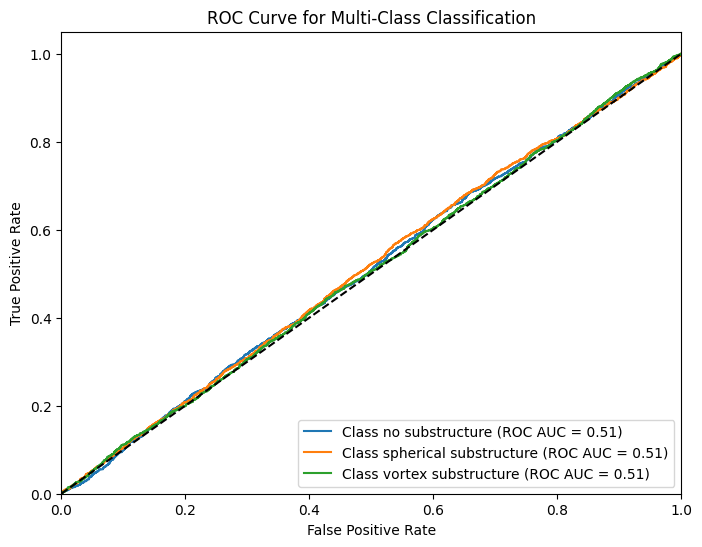

TrainLoss =  1.1019822362263998   ValidationLoss =  1.0991147664388021
lr =  0.0004000144752546505
Best Model Saved
Epoch no. = 2
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:19<00:00, 11.80it/s]


Accuracy: 0.3430666666666667
ROC AUC Score: 0.50678112


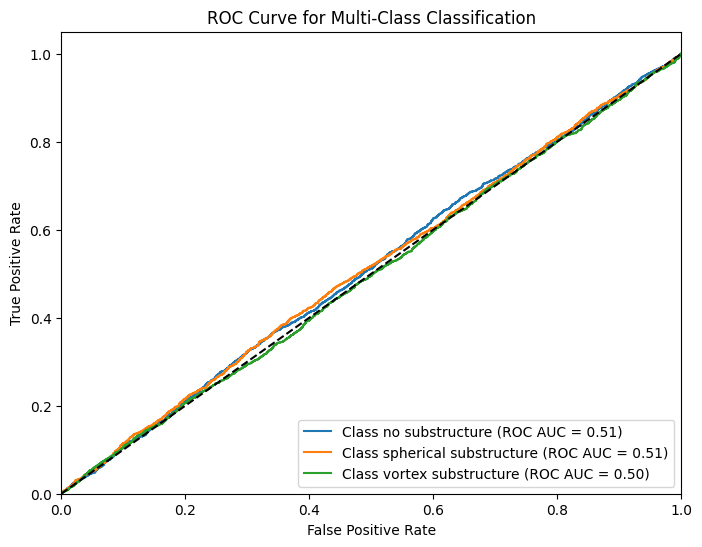

TrainLoss =  1.0993832177480063   ValidationLoss =  1.0987599276224773
lr =  0.0004000144659097645
Best Model Saved
Epoch no. = 3
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.13it/s]


Accuracy: 0.3350666666666667
ROC AUC Score: 0.5125859066666667


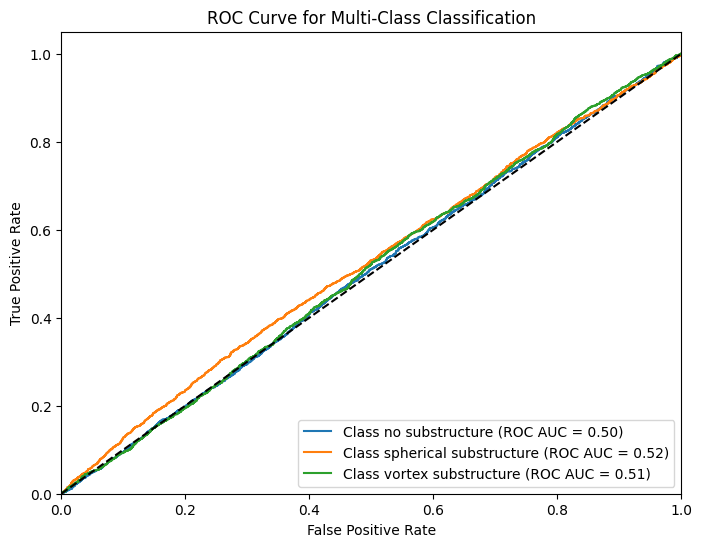

TrainLoss =  1.0980649188995362   ValidationLoss =  1.1006233189264933
lr =  0.0004000145150169325
Epoch no. = 4
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.73it/s]


Accuracy: 0.3333333333333333
ROC AUC Score: 0.5217056533333334


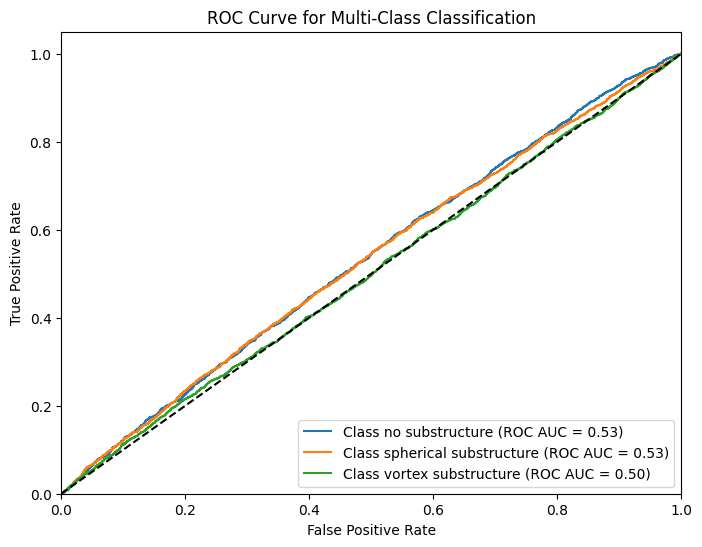

TrainLoss =  1.0962672439575196   ValidationLoss =  1.1126809911727906
lr =  0.0004000148347919324
Epoch no. = 5
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:22<00:00, 10.57it/s]


Accuracy: 0.3372
ROC AUC Score: 0.5835000266666667


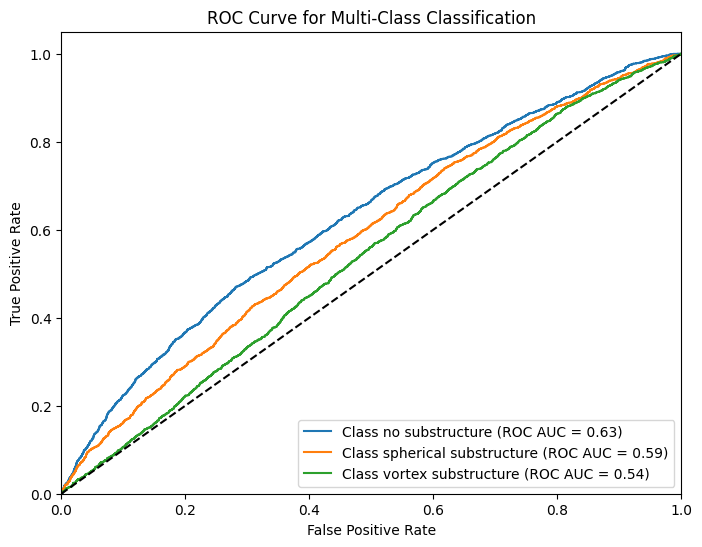

TrainLoss =  1.0733467882792156   ValidationLoss =  1.324193038113912
lr =  0.00040002101080196563
Epoch no. = 6
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.07it/s]


Accuracy: 0.4508
ROC AUC Score: 0.7452836666666666


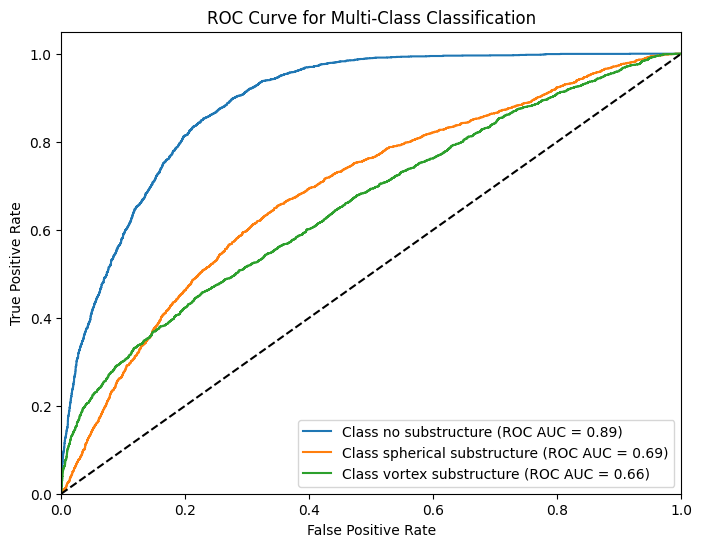

TrainLoss =  0.9217680569330852   ValidationLoss =  1.2740697086016337
lr =  0.00040001945030577156
Epoch no. = 7
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.28it/s]


Accuracy: 0.6912
ROC AUC Score: 0.8679239066666667


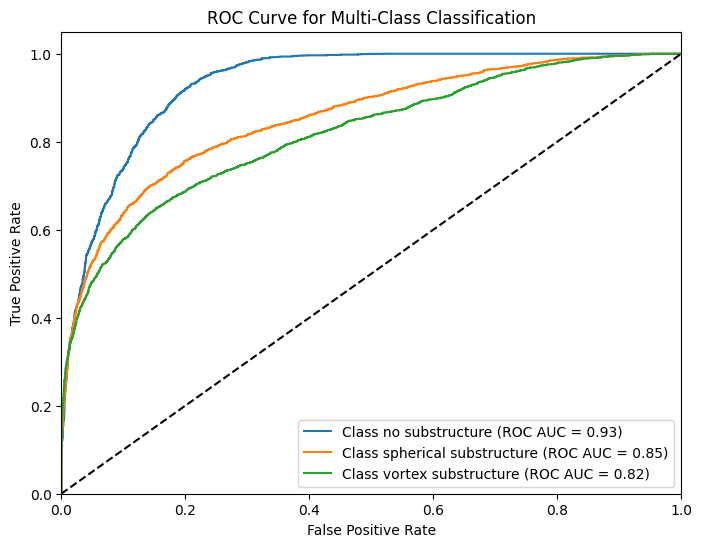

TrainLoss =  0.6926107804934184   ValidationLoss =  0.8417490591367086
lr =  0.00040000848995712206
Best Model Saved
Epoch no. = 8
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.93it/s]


Accuracy: 0.8142666666666667
ROC AUC Score: 0.9381824266666667


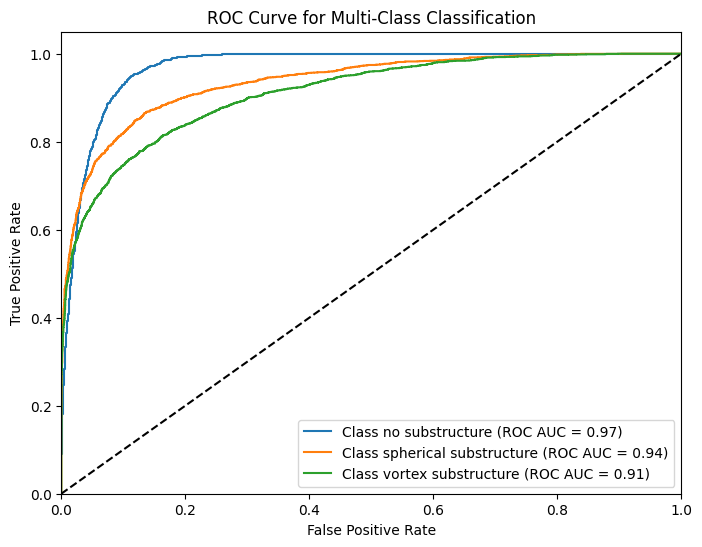

TrainLoss =  0.511047979927063   ValidationLoss =  0.4668298477331797
lr =  0.00040000261130462497
Best Model Saved
Epoch no. = 9
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:24<00:00,  9.44it/s]


Accuracy: 0.7949333333333334
ROC AUC Score: 0.94241936


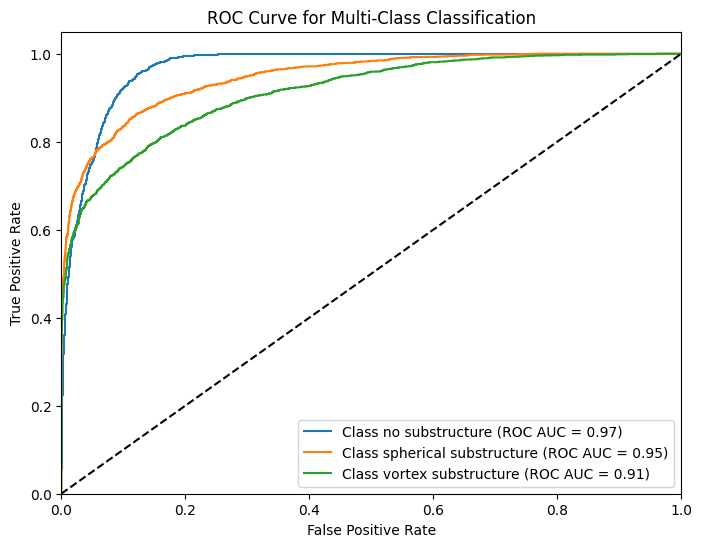

TrainLoss =  0.4100049288034439   ValidationLoss =  0.5639421380996704
lr =  0.00040000381074055055
Epoch no. = 10
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.97it/s]


Accuracy: 0.8274666666666667
ROC AUC Score: 0.95637392


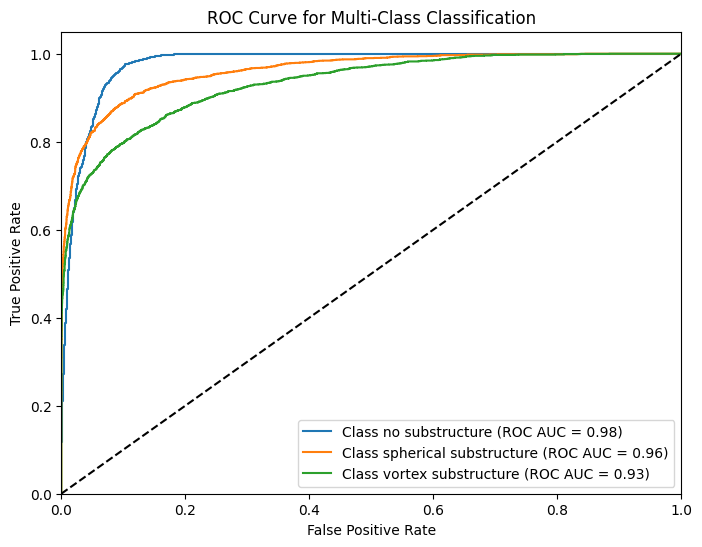

TrainLoss =  0.33686436014175414   ValidationLoss =  0.41959006454149883
lr =  0.0004000021095542858
Best Model Saved
Epoch no. = 11
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.81it/s]


Accuracy: 0.8386666666666667
ROC AUC Score: 0.9588135333333333


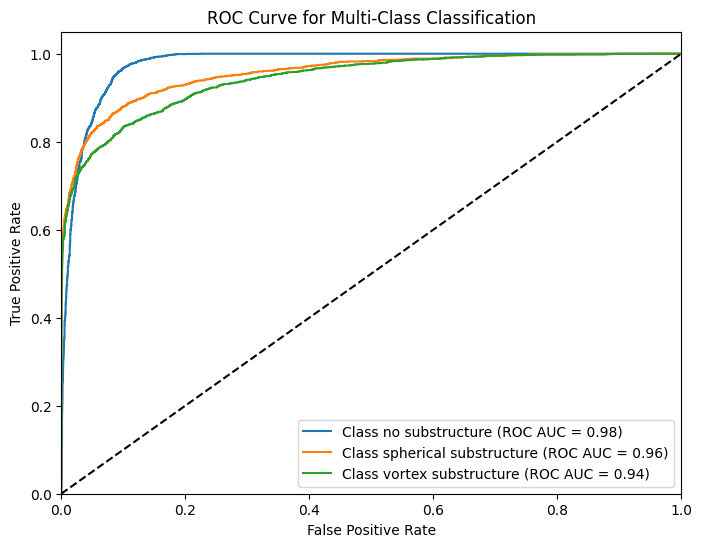

TrainLoss =  0.286448158009847   ValidationLoss =  0.5079797443389893
lr =  0.00040000309195446435
Epoch no. = 12
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 13.92it/s]


Accuracy: 0.8730666666666667
ROC AUC Score: 0.96796504


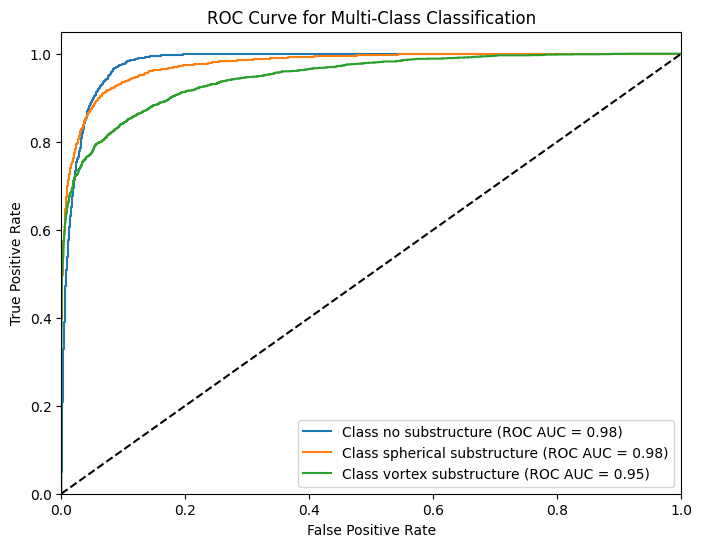

TrainLoss =  0.2551212087949117   ValidationLoss =  0.3450256266872088
lr =  0.000400001426405585
Best Model Saved
Epoch no. = 13
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.37it/s]


Accuracy: 0.7298666666666667
ROC AUC Score: 0.9596586799999999


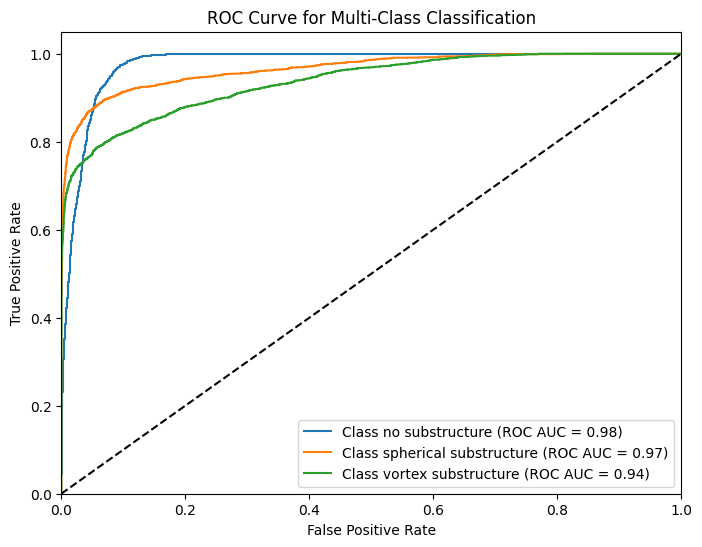

TrainLoss =  0.22630946358044943   ValidationLoss =  0.6424492803255717
lr =  0.0004000049455883548
Epoch no. = 14
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.17it/s]


Accuracy: 0.6642666666666667
ROC AUC Score: 0.91136972


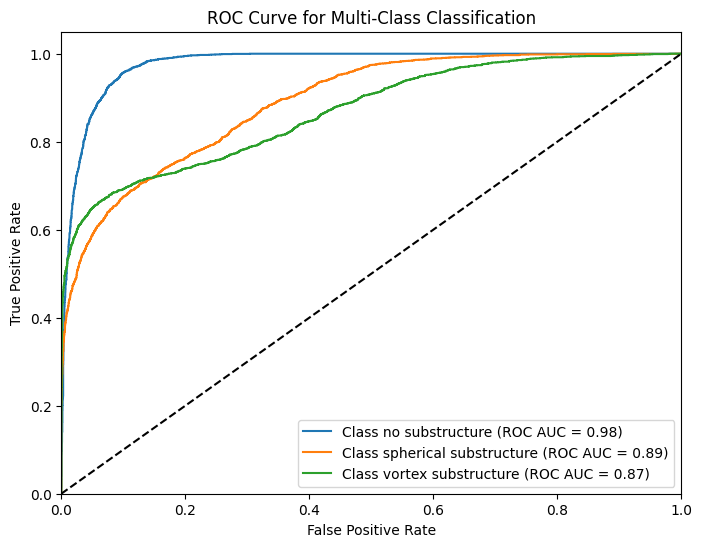

TrainLoss =  0.20101200686494508   ValidationLoss =  1.5858823982874553
lr =  0.00040003013573922455
Epoch no. = 15
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:24<00:00,  9.74it/s]


Accuracy: 0.8922666666666667
ROC AUC Score: 0.97684448


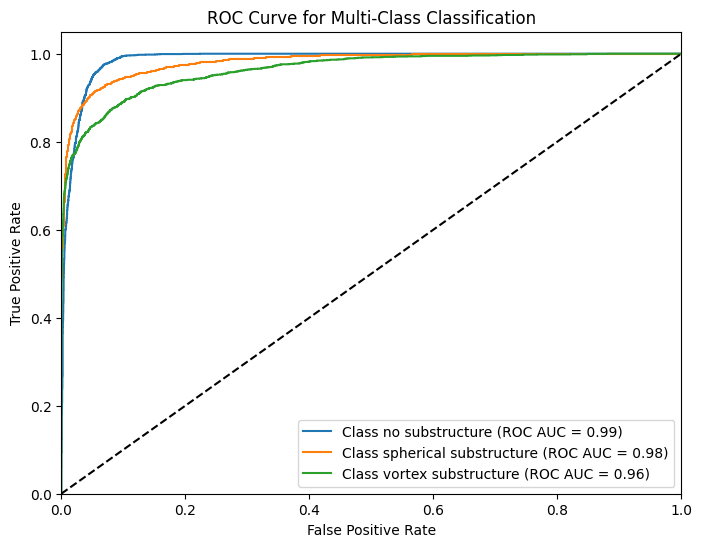

TrainLoss =  0.18001089583039284   ValidationLoss =  0.3245198873837789
lr =  0.00040000126189424466
Best Model Saved


In [ ]:
trainloss =[]
valloss = []
bestloss = np.inf
for i in range(config.EPOCHS):
    print("Epoch no. =" ,i+1)
    print("-"*80)
    trainl = trainer(model,trainloader,optimizer,criterion,device)
    vall = tester(model,testloader,criterion,device)
    trainloss.append(trainl)
    valloss.append(vall)
    scheduler.step(vall)
    print("TrainLoss = ",trainl," ","ValidationLoss = ",vall)
    lr=scheduler.get_last_lr()[0]
    print("lr = ",lr)
    if bestloss>vall:
        bestloss = vall
        torch.save({
            'model':model.state_dict(),
            'optimizer':optimizer.state_dict()},
        './Bestmodel.model'
        )
        print("Best Model Saved")
    print("="*80)